In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Constants import Constants
from astropy.io import ascii
from astropy.table import Table,join,MaskedColumn
import seaborn as sns

c=Constants()

%matplotlib inline

plt.rcParams['figure.figsize'] = (5,4)
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.borderpad'] = 0.2
plt.rcParams['legend.labelspacing'] = 0.2
plt.rcParams['legend.handletextpad'] = 0.2
plt.rcParams['font.family'] = 'stixgeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 16


import importlib.metadata


import pkg_resources

def print_package_version(package_name):
    try:
        version = pkg_resources.get_distribution(package_name).version
        print(f"{package_name} version: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"Package '{package_name}' not found.")
    

print_package_version("numpy")
print_package_version("matplotlib")
print_package_version("astropy")
print_package_version("SEDFit")
print_package_version("isochrones")

Constants defined...
numpy version: 2.2.6
matplotlib version: 3.10.1
astropy version: 7.0.0
Package 'SEDFit' not found.
isochrones version: 2.1


/var/folders/60/1rg8nv516mb287lhl_lqcz_00000gq/T/ipykernel_66834/3392830101.py:26: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [2]:
def a_RL(q):
    """Eggelton formula, q=M2/M1 (opposite of eggelton deff)"""
    return (0.6*q**(-2./3.) + np.log(1+q**(-1./3.)))/(0.49*q**(-2./3.))

def omega_pseudo_factor_rp(ecc):
    """omega_pseudo = omega_pseudo_factor * omega_orb(rp) """
    return (1+7.5*ecc**2 + 45/8.*ecc**4 + 5/16.*ecc**6)/((1+3*ecc**2 +3/8.*ecc**4)*(1-ecc**2)**1.5) * (1-ecc)**1.5

def omega_peri_factor_rp(ecc):
    """ omega_peri = omega_peri_factor * omega_orb(rp) """
    return (1+ecc)**0.5 #/(1-ecc)**1.5

def omega_pseudo_factor(ecc):
    """omega_pseudo = omega_pseudo_factor * omega_orb(a) """
    return (1+7.5*ecc**2 + 45/8.*ecc**4 + 5/16.*ecc**6)/((1+3*ecc**2 +3/8.*ecc**4)*(1-ecc**2)**1.5) 

def omega_peri_factor(ecc):
    """ omega_peri = omega_peri_factor * omega_orb(a) """
    return (1+ecc)**0.5 /(1-ecc)**1.5

def Omega_RL(M,R,q=1):
    return np.sqrt(c.G*M/(a_RL(q)*R)**3)



In [3]:


# ------------------------------------------------------------
# 1. A(f, e, nu) from equation (21), vectorized
# ------------------------------------------------------------

def A_param(f, e, nu):
    """
    Parameter A(f, e, nu) as defined in Sepinsky et al. (2007), eq. (21).
    Works with scalars or arrays (broadcasting via numpy).
    """
    f = np.asarray(f, dtype=float)
    e = np.asarray(e, dtype=float)
    nu = np.asarray(nu, dtype=float)
    return f**2 * (1.0 + e)**4 / (1.0 + e * np.cos(nu))**3


# ------------------------------------------------------------
# 2. Eggleton Roche lobe radius from equation (46), vectorized
# ------------------------------------------------------------

def eggleton_rl(q, D):
    """
    Eggleton (1983) Roche lobe radius for a star of mass ratio q = M1/M2,
    using the instantaneous separation D (Sepinsky et al. eq. 46).
    Works with scalars or arrays.
    """
    q = np.asarray(q, dtype=float)
    D = np.asarray(D, dtype=float)

    q13 = q**(1.0/3.0)
    q23 = q13**2
    return D * 0.49 * q23 / (0.6 * q23 + np.log(1.0 + q13))


# ------------------------------------------------------------
# 3. RL / RL_Egg as function of q, A using eqs. (47)–(52), vectorized
# ------------------------------------------------------------

def roche_lobe_ratio(q, A):
    """
    Ratio of the true volume-equivalent Roche lobe radius to the Eggleton
    radius, R_L / R_L^Egg, using the fitting formulae in Sepinsky et al.
    (2007) eqs. (47)–(52).

    Works with scalars or arrays. If both q and A are scalars, returns a scalar.
    Otherwise returns a numpy array with broadcasted shape.
    """
    # Track whether inputs were scalar to decide return type
    scalar_input = np.isscalar(q) and np.isscalar(A)

    # Broadcast to common shape and ensure at least 1D
    q_arr = np.atleast_1d(np.array(q, dtype=float))
    A_arr = np.atleast_1d(np.array(A, dtype=float))

    # Broadcast manually
    q_b, A_b = np.broadcast_arrays(q_arr, A_arr)

    logq = np.log10(q_b)
    logA = np.log10(A_b)

    ratio = np.empty_like(logq, dtype=float)

    # Region masks (same partition as eqs. 47–52)
    m1 = (logq <= 0) & (logA <= -0.1)                    # eq. (47)
    m2 = (logq >= 0) & (logA <= -0.1)                    # eq. (48)
    m3 = (logq >= 0) & (logA >= -0.1) & (logA <= 0.2)    # eq. (49)
    m4 = (logq <= 0) & (logA >= -0.1) & (logA <= 0.2)    # eq. (50)
    m5 = (logq >= 0) & (logA >= 0.2)                     # eq. (51)
    m6 = (logq <= 0) & (logA >= 0.2)                     # eq. (52)

    # --- Eq. (47): log q <= 0, log A <= -0.1
    if np.any(m1):
        A1 = A_b[m1]
        lq1 = logq[m1]
        ratio[m1] = (1.226
                     - 0.21 * A1
                     - 0.15 * (1.0 - A1)
                     * np.exp((0.25 * A1 - 0.3) * lq1**1.55))

    # --- Eq. (48): log q >= 0, log A <= -0.1
    if np.any(m2):
        A2 = A_b[m2]
        lq2 = logq[m2]
        ratio[m2] = (1.0
                     + 0.11 * (1.0 - A2)
                     - 0.05 * (1.0 - A2)
                     * np.exp(-(0.5 * (1.0 + A2) + lq2)**2))

    # --- Eq. (49): log q >= 0, -0.1 <= log A <= 0.2
    if np.any(m3):
        lA3 = logA[m3]
        lq3 = logq[m3]
        g0 = 0.9978 - 0.1229 * lA3 - 0.1273 * lA3**2
        g1 = 0.001 + 0.02556 * lA3
        g2 = 0.0004 + 0.0021 * lA3
        ratio[m3] = g0 + g1 * lq3 + g2 * lq3**2

    # --- Eq. (50): log q <= 0, -0.1 <= log A <= 0.2
    if np.any(m4):
        lA4 = logA[m4]
        lq4 = logq[m4]
        h0 = 1.0071 - 0.0907 * lA4 - 0.0495 * lA4**2
        h1 = -0.004 - 0.163 * lA4 - 0.214 * lA4**2
        h2 = 0.00022 - 0.0108 * lA4 - 0.02718 * lA4**2
        ratio[m4] = h0 + h1 * lq4 + h2 * lq4**2

    # --- Eq. (51): log q >= 0, log A >= 0.2
    if np.any(m5):
        lA5 = logA[m5]
        lq5 = logq[m5]

        i0 = (6.3014 * lA5**1.3643 *
              (np.exp(2.3644 * lA5**0.70748)
               - 1.4413 * np.exp(-1.84e-5 * lA5**(-4.5693))))
        i1 = (lA5**(-0.0015) * np.exp(8.84 * lA5**0.282) + 15.78)
        i2 = (1.0
              + 0.036 * np.exp(8.01 * lA5**0.879)
              - 0.105 * np.exp(7.91 * lA5**0.879))
        i3 = (0.991
              / (1.38 * np.exp(-0.035 * lA5**0.76)
                 + 23.0 * np.exp(-2.89 * lA5**0.76)))

        ratio[m5] = i0 + i1 * np.exp(-i2 * (lq5 + i3)**2)

    # --- Eq. (52): log q <= 0, log A >= 0.2
    if np.any(m6):
        lA6 = logA[m6]
        lq6 = logq[m6]

        j0 = (1.895 * lA6**0.837 *
              np.exp(1.636 * lA6**0.789) - 1.0)
        j1 = (4.3 * lA6**0.98 *
              np.exp(2.5 * lA6**0.66) + 4.7)
        j2 = (1.0 /
              (8.8 * np.exp(-2.95 * lA6**0.76)
               + 1.64 * np.exp(-0.03 * lA6**0.76)))
        j3 = (0.256 * np.exp(-1.33 * lA6**2.9)
              - 5.5 * np.exp(1.33 * lA6**2.9) + 1.0)

        ratio[m6] = j0 + j1 * np.exp(-j2 * np.abs(lq6)**j3)

    # Return scalar if both inputs were scalar
    if scalar_input:
        return float(ratio[0])
    return ratio


# ------------------------------------------------------------
# 4. Full RL using ratio * Eggleton, vectorized
# ------------------------------------------------------------

def roche_lobe_radius(q, A, D):
    """
    Full volume-equivalent Roche lobe radius for star 1:

        R_L = (R_L / R_L^Egg)(q, A) * R_L^Egg(q, D)

    Works with scalars or arrays; broadcasting is handled.
    """
    return roche_lobe_ratio(q, A) * eggleton_rl(q, D)


# ------------------------------------------------------------
# 5. Wrapper: RL at periapse from Porb, Mtot, q, f, e (CGS), vectorized
# ------------------------------------------------------------

def roche_lobe_radius_periapse(Porb, Mtot, q, f, e, G=c.G):
    """
    Volume-equivalent Roche lobe radius of star 1 at periapse (cgs).

    Parameters
    ----------
    Porb : float or array
        Orbital period (s).
    Mtot : float or array
        Total mass M1 + M2 (g).
    q : float or array
        Mass ratio M1/M2.
    f : float or array
        Spin/orbit frequency ratio at periapse, f = Omega_spin / Omega_P.
    e : float or array
        Orbital eccentricity (0 <= e < 1).
    G : float, optional
        Gravitational constant in cgs (default: 6.67430e-8).

    Returns
    -------
    RL_peri : float or array
        Volume-equivalent Roche lobe radius at periapse (cm).
        Scalar if all inputs are scalars, otherwise numpy array.
    """
    # Track scalar vs array
    scalar_input = (np.isscalar(Porb) and np.isscalar(Mtot) and
                    np.isscalar(q) and np.isscalar(f) and np.isscalar(e))

    # Broadcast all inputs
    Porb_arr = np.asarray(Porb, dtype=float)
    Mtot_arr = np.asarray(Mtot, dtype=float)
    q_arr    = np.asarray(q,    dtype=float)
    f_arr    = np.asarray(f,    dtype=float)
    e_arr    = np.asarray(e,    dtype=float)

    Porb_b, Mtot_b, q_b, f_b, e_b = np.broadcast_arrays(
        Porb_arr, Mtot_arr, q_arr, f_arr, e_arr
    )

    # 1. Kepler's law: a^3 = G Mtot P^2 / (4π^2)
    a = (G * Mtot_b * Porb_b**2 / (4.0 * np.pi**2))**(1.0 / 3.0)

    # 2. Periapse separation
    D_peri = a * (1.0 - e_b)

    # 3. A(f, e, nu=0) at periapse
    A_b = A_param(f_b, e_b, nu=0.0)

    # 4. Roche lobe radius at periapse
    RL_peri = roche_lobe_radius(q_b, A_b, D_peri)

    if scalar_input:
        return float(RL_peri[0])
    return RL_peri

In [4]:
### JOIN AND WRITE TABLE!

# Read and select LMC, SMC
def read_ogle(filename):
    # NOTE: need to apply diff dist moduli 
    def get_loc(name):
        return name[5:8]
    get_loc=np.vectorize(get_loc)


    hb = Table.read(filename,header_start=6,data_start=7,format='ascii')
    hb['loc'] = get_loc(hb['ID'])
    return hb

def join_save_hb():
    hbo = read_ogle("SEDFitting/query_1683478037.14515r.txt")
    hbo = hbo[hbo['loc']!='BLG'].copy()

    sed = Table.read("SEDFitting/speedyfit/hb_sed_speedyfit.csv")
    sed['ID'] = [id_str.replace(" ", "-") for id_str in sed['ID']]

    hb = join(hbo,sed, keys='ID', join_type='left')

    hb.write("ogle_hb_seds.csv",overwrite=True)
    
    return hb

hb = join_save_hb()
hb.keys()


['ID',
 'Type',
 'RA',
 'Decl',
 'I',
 'V',
 'V_I',
 'P',
 'T0',
 'A',
 'Ecc',
 'Incl',
 'Peri',
 'Model',
 'loc',
 'teff',
 'teff_err-',
 'teff_err+',
 'logg',
 'logg_err-',
 'logg_err+',
 'L',
 'L_err-',
 'L_err+',
 'rad',
 'rad_err-',
 'rad_err+',
 'ebv',
 'ebv_err-',
 'ebv_err+']

In [5]:
# READ THE TABLE, ADD columns
gamma = 1.4
hb = Table.read("ogle_hb_seds.csv")
hb['Pcirc'] = hb['P'] * (1-hb['Ecc']**2)**1.5
hb['cs'] = np.sqrt(gamma*c.kB* hb['teff']/(0.6*c.mp))
hb['Omega_orb'] = 2*np.pi/(hb['P']*86400)
hb['Omega_peri'] = omega_peri_factor(hb['Ecc'])*hb['Omega_orb']
hb['Omega_pseudo'] = omega_pseudo_factor(hb['Ecc'])*hb['Omega_orb']
hb['AoRcrit_zero']  = (hb['cs']/hb['Omega_peri']) / (hb['rad']*c.rsun)
hb['Omega_tide_pseudo'] = (hb['Omega_peri']-hb['Omega_pseudo'])
hb['AoRcrit_pseudo']  = (hb['cs']/hb['Omega_tide_pseudo']) / (hb['rad']*c.rsun)

def p_cut(rstar):
    return 2*np.pi*np.sqrt( (2*a_RL(2)*rstar*c.rsun)**3/(c.G*0.5*c.msun) )/86400.
#hb['tidal_flag'] = hb['Pcirc']<p_cut(hb['rad'])
hb['tidal_flag'] = (roche_lobe_radius_periapse( hb['P'] * 86400 , Mtot = 2*c.msun, q=1, f=0, e=hb['Ecc'])  / (hb['rad']*c.rsun ) < 3)



# supply adjusted amplitude estimates for a few stars
hb['A_adjust'] = np.nan
A_adjust_dict = {'OGLE-LMC-HB-0020':0.35,
                 'OGLE-LMC-HB-0032':0.05,
                 'OGLE-LMC-HB-0341':0.01,
                 'OGLE-LMC-HB-0347':0.02,
                 'OGLE-LMC-HB-0408':0.15,
                 'OGLE-SMC-HB-0007':0.3}
for i in range(len(hb)):
    if hb['ID'][i] in A_adjust_dict:
        hb['A_adjust'][i] = A_adjust_dict[hb['ID'][i]]
# amplitude including adjusted values
hb['A_hb'] = np.where(np.isnan(hb['A_adjust']),hb['A'],hb['A_adjust'])


hb['f_crit_zero'] = hb['A_hb']/hb['AoRcrit_zero']
hb['f_crit_pseudo'] = hb['A_hb']/hb['AoRcrit_pseudo']



print(hb.keys())


['ID', 'Type', 'RA', 'Decl', 'I', 'V', 'V_I', 'P', 'T0', 'A', 'Ecc', 'Incl', 'Peri', 'Model', 'loc', 'teff', 'teff_err-', 'teff_err+', 'logg', 'logg_err-', 'logg_err+', 'L', 'L_err-', 'L_err+', 'rad', 'rad_err-', 'rad_err+', 'ebv', 'ebv_err-', 'ebv_err+', 'Pcirc', 'cs', 'Omega_orb', 'Omega_peri', 'Omega_pseudo', 'AoRcrit_zero', 'Omega_tide_pseudo', 'AoRcrit_pseudo', 'tidal_flag', 'A_adjust', 'A_hb', 'f_crit_zero', 'f_crit_pseudo']


/var/folders/60/1rg8nv516mb287lhl_lqcz_00000gq/T/ipykernel_66834/1928255425.py:58: RuntimeWarning: divide by zero encountered in log10
  logA = np.log10(A_b)


In [6]:
hb[hb['tidal_flag']==False]

ID,Type,RA,Decl,I,V,V_I,P,T0,A,Ecc,Incl,Peri,Model,loc,teff,teff_err-,teff_err+,logg,logg_err-,logg_err+,L,L_err-,L_err+,rad,rad_err-,rad_err+,ebv,ebv_err-,ebv_err+,Pcirc,cs,Omega_orb,Omega_peri,Omega_pseudo,AoRcrit_zero,Omega_tide_pseudo,AoRcrit_pseudo,tidal_flag,A_adjust,A_hb,f_crit_zero,f_crit_pseudo
str16,str2,str11,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str3,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64
OGLE-LMC-HB-0030,MS,04:55:31.22,-69:28:05.5,16.516,16.656,0.14,395.067,9386.9,0.097,0.4619,35.15,35.4,0,LMC,15701.354350088139,1947.3775825367338,2017.697461138756,3.351906615133454,0.4592299297814906,0.6565635148034499,2429.251067359561,770.0858282047038,1196.9040018674436,6.574132151510114,0.42889764065741254,0.5292999719390616,0.16402890847662638,0.04070368048220152,0.03721591815983105,275.63968297404796,1739006.1486601885,1.84075238292316e-07,5.638449775920822e-07,4.5521461909885074e-07,6.745370935072972,1.0863035849323143e-07,35.01179206707195,False,nan,0.097,0.01438023215234058,0.0027704951467259226
OGLE-LMC-HB-0122,MS,05:10:47.57,-70:10:46.6,14.799,15.025,0.226,259.478,9145.82,0.097,0.4055,65.2,56.8,1,LMC,15304.013264041849,3725.409088554912,3116.1476601227223,2.8967253122865015,0.37518307705595966,0.5324437178677122,10945.697315351092,5272.191341665666,8894.041724142757,14.453034730117368,1.6984958676611797,2.7605764622326507,0.15891245542121024,0.06629249693490269,0.05995074607208517,198.18674511776942,1716861.3615063718,2.8026288227298805e-07,7.248584742954352e-07,5.82514047918626e-07,2.3562741871786814,1.4234442637680918e-07,11.998821139780981,False,nan,0.097,0.041166686172522365,0.008084127504693396
OGLE-LMC-HB-0167,MS,05:16:25.41,-69:28:55.2,15.065,15.312,0.247,242.67,9056.6,0.038,0.152,21.32,22.3,0,LMC,15308.25572130921,2886.9986724885803,2777.788714566059,2.949813094224557,0.3895798472779455,0.5357644382690245,8696.923466231601,3927.4973261784935,5840.925877371432,13.219205214391415,1.2441041844413032,1.7467012333719296,0.14904095052938587,0.06483872817443549,0.05734651052485962,234.3087931650444,1717099.3123667543,2.996746699898232e-07,4.118911843410764e-07,3.413539250370615e-07,4.534301960494919,7.05372593040149e-08,26.477340105018982,False,nan,0.038,0.00838056228523702,0.001435189480864689
OGLE-LMC-HB-0281,MS,05:29:13.46,-67:00:08.7,15.482,15.551,0.069,158.022,9139.24,0.203,0.209,89.7,76.39,0,LMC,16772.103281259944,2582.8092220731487,2164.3678559229666,3.037991895968242,0.46302502233213394,0.6134636780279616,8273.675109286289,2738.4631459722214,5057.18314593178,10.400103306096925,0.7460589785789189,1.100816870074171,0.1231851382578096,0.04299210233441053,0.040485591744562566,147.78206496017842,1797323.795462338,4.602020741822683e-07,7.192783641325012e-07,5.819230905594134e-07,3.4545743145525627,1.373552735730878e-07,18.09031788228606,False,nan,0.203,0.058762666978924905,0.01122147224393312
OGLE-LMC-HB-0289,MS,05:29:51.27,-71:57:10.1,16.346,16.544,0.198,2555.5,10621.9,0.182,0.4564,50.77,38.4,0,LMC,17504.972112536558,3066.8910698145974,2840.778168158402,3.4563894367740486,0.47310353578421305,0.6401189380225629,3055.688772119026,1132.0084709077285,1702.3697349752201,5.915678842912004,0.5788161376641812,0.8976252153421393,0.12518065110175725,0.03737090252311023,0.034606087795544194,1800.1805404946467,1836171.6245825225,2.8457073827599452e-08,8.568630267550892e-08,6.914644154544808e-08,52.08349810743918,1.6539861130060837e-08,269.8234494316407,False,nan,0.182,0.0034943889449315733,0.0006745151334450988
OGLE-SMC-HB-0025,MS,00:56:25.81,-72:22:15.1,16.113,16.104,-0.009,186.397,9077.2,0.053,0.2566,43.8,179.9,0,SMC,15183.959104279193,2107.0745513020192,2312.335644122706,3.1884326304823705,0.563638349716856,0.5885723510891112,4919.279389799687,1706.8923368420915,3000.3059039656664,9.95572917504216,0.

In [8]:
# Compare to wrona L,T estimates
from isochrones.mist.bc import MISTBolometricCorrectionGrid

def get_wrona_lt_table():
    bc_grid = MISTBolometricCorrectionGrid(['I'])
    bc_grid.interp.index_names

    # read extinction https://ogle.astrouw.edu.pl/cgi-ogle/get_ms_ext.py
    ext = Table.read('SEDFitting/ogle_ext.txt',format='ascii')
    ext['E(B-V)']=ext['E(V-I)']/1.318 # below Eq 12, Wrona 2022

    if len(ext)!=len(hb):
        raise Exception("TABLES DO NOT SEEM TO MATCH")

    # OGLE TABLE
    hbo = read_ogle("SEDFitting/query_1683478037.14515r.txt")
    hbo = hbo[hbo['loc']!='BLG'].copy()

        
    ## GET THE MASSEY 2002 x-matched data
    hbm = Table.read("1746632302418A.csv") 
    _, idx = np.unique(hbm['ID'], return_index=True) # take first index of duplicates, smallest angular distance
    hbw = join(hbo, hbm['ID','Vmag_1','B-V','U-B','V-R'][idx],keys='ID', join_type='left')

    ## 
    hbz = Table.read("1746699330847A.csv")[['ID','Umag','Bmag','Vmag_1']]
    _, idx = np.unique(hbz['ID'],return_index=True)
    #hbz[idx]

    hbz['B-V'] = hbz['Bmag']-hbz['Vmag_1']
    hbz['U-B'] = hbz['Umag']-hbz['Bmag']

    hbj = join(hbw,hbz[idx],keys='ID',join_type='left')

    # COMBINE COLUMNS 
    def combine_cols(table,name1,name2,name_combined):
        # Combine: use col1 if not masked, else col2
        combined = np.where(~table[name1].mask, table[name1], table[name2])

        # Optional: mask result if both are masked
        combined_mask = table[name1].mask & table[name2].mask
        combined_column = MaskedColumn(combined, mask=combined_mask, name=name_combined)

        return combined_column


    hbj['B-V'] = combine_cols(hbj,'B-V_1','B-V_2','B-V')
    hbj['U-B'] = combine_cols(hbj,'U-B_1','U-B_2','U-B')


    # now apply extinction/Teff/etc
    hbj['Q'] = hbj['U-B'] - 0.72*hbj['B-V']
    hbj['(B-V)0'] = hbj['B-V']-ext['E(B-V)']
    hbj['(V-I)0'] = hbj['V_I']-ext['E(V-I)']

    hbj['Av'] = 3.1*ext['E(B-V)']
    hbj['AI'] = hbj['Av']/1.805
    hbj['I0'] = hbj['I']-hbj['AI']

    def Teff_hot(Q,BV0):
        y1 = 3.994-0.267*Q + 0.364*Q**2
        y2 = 3.990-0.510*BV0
        y3 = 3.96-0.344*BV0
        return 10**(np.ones_like(Q)*np.where(BV0<0.2,
                                                  np.where(BV0<0.0,y1,y2),
                                                  y3) )
    def Teff_cool(VI0):
        return 8556.22 - 5235.57*VI0 + 1471.09*VI0**2

    def Mbol(I0,Teff,Av,Type,Loc):
        dist = np.where( Loc=='LMC',49.59e3, 62.44e3) # distance to lmc or smc
        if Type =='MS':
            return np.where(Teff>0,I0 -5*np.log10(dist) + 5 +  bc_grid.interp([Teff,4.5,-0.5,Av]),np.nan)
        else:
            return np.where(Teff>0,I0 -5*np.log10(dist) + 5 +  bc_grid.interp([Teff,0.5,-0.5,Av]),np.nan)
    Mbol = np.vectorize(Mbol)

    # apply one of the two teff formulas
    hbj['Teff'] = np.where(hbj['Type']=='MS',
                          Teff_hot(hbj['Q'],hbj['(B-V)0']),
                          Teff_cool(hbj['(V-I)0']))

    hbj['Mbol'] = Mbol(hbj['I0'],hbj['Teff'],hbj['Av'],hbj['Type'],hbj['loc'])
    hbj['Lbol'] = 10**(-0.4*(hbj['Mbol']-4.74) )

    return hbj


hbw = get_wrona_lt_table()
hbw.keys()

PyMultiNest not imported.  MultiNest fits will not work.


['ID',
 'Type',
 'RA',
 'Decl',
 'I',
 'V',
 'V_I',
 'P',
 'T0',
 'A',
 'Ecc',
 'Incl',
 'Peri',
 'Model',
 'loc',
 'Vmag_1_1',
 'B-V_1',
 'U-B_1',
 'V-R',
 'Umag',
 'Bmag',
 'Vmag_1_2',
 'B-V_2',
 'U-B_2',
 'B-V',
 'U-B',
 'Q',
 '(B-V)0',
 '(V-I)0',
 'Av',
 'AI',
 'I0',
 'Teff',
 'Mbol',
 'Lbol']

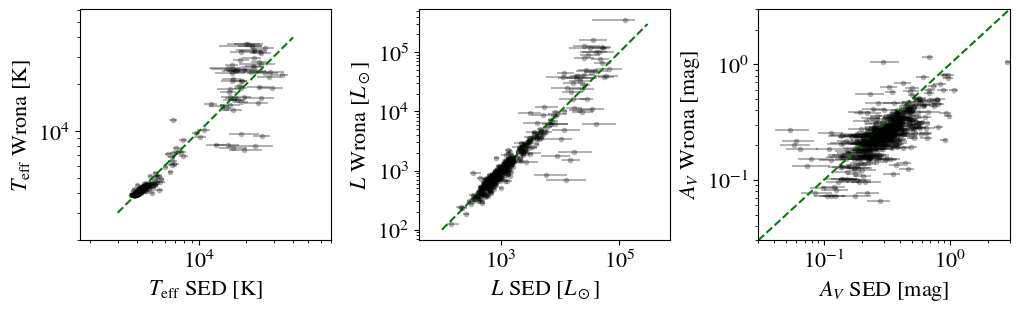

In [9]:
plt.figure(figsize=(12, 3))
myms = 4

plt.subplot(131)
plt.errorbar(hb['teff'], hbw['Teff'], xerr=[hb['teff_err-'], hb['teff_err+']], 
             alpha=0.3, ls='', marker='o', markersize=myms, markeredgecolor='none',color='k')
plt.loglog()
plt.axis('equal')
xp = np.linspace(3000, 40000)
plt.plot(xp, xp, 'g--')
plt.ylim(2e3,)  # Now the "y" axis is the original x
plt.xlabel(r'$T_{\rm eff}$ SED [K]')
plt.ylabel(r'$T_{\rm eff}$ Wrona [K]')

plt.subplot(132)
plt.errorbar(hb['L'], hbw['Lbol'], xerr=[hb['L_err-'], hb['L_err+']], 
             alpha=0.3, ls='', marker='o', markersize=myms, markeredgecolor='none',color='k')
plt.loglog()
plt.axis('equal')
xp = np.linspace(100, 3e5)
plt.plot(xp, xp, 'g--')
plt.xlabel(r'$L$ SED [$L_\odot$]')
plt.ylabel(r'$L$ Wrona [$L_\odot$]')

plt.subplot(133)
plt.errorbar(3.1 * hb['ebv'], hbw['Av'], xerr=[hb['ebv_err-'], hb['ebv_err+']], 
             alpha=0.3, ls='', marker='o', markersize=myms, markeredgecolor='none',color='k')
plt.loglog()
xp = np.linspace(3e-2, 3)
plt.plot(xp, xp, 'g--')
plt.xlim(3e-2, 3)
plt.ylim(3e-2, 3)
plt.xlabel(r'$A_V$ SED [mag]')
plt.ylabel(r'$A_V$ Wrona [mag]')

plt.subplots_adjust(wspace=0.35)
plt.savefig("figs/SP_compare.pdf",bbox_inches='tight',dpi=300)

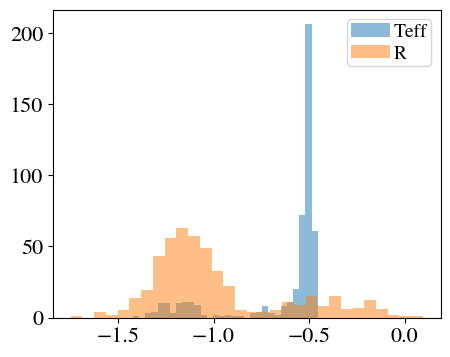

In [10]:
## Errors
plt.hist( np.log10( np.mean(hb['teff_err+']+hb['teff_err-']) / hb['teff']) ,bins=30 ,label='Teff',alpha=0.5)
plt.hist( np.log10( np.mean(hb['rad_err+']+hb['rad_err-']) / hb['rad']) ,bins=30,label='R',alpha=0.5)
plt.legend()


In [11]:
from isochrones.mist import MIST_BasicEvolutionTrack

mist = MIST_BasicEvolutionTrack()
df = mist.model_grid.df

def get_track(df,initial_feh,initial_mass):
    return df.xs((initial_feh,initial_mass))

#get_track(df,-1,1.01)

print("masses=", np.unique( np.round(df.initial_mass,1) ) )

masses= [1.00e-01 2.00e-01 3.00e-01 4.00e-01 5.00e-01 6.00e-01 7.00e-01 8.00e-01
 9.00e-01 1.00e+00 1.10e+00 1.20e+00 1.30e+00 1.40e+00 1.50e+00 1.60e+00
 1.70e+00 1.80e+00 1.90e+00 2.00e+00 2.10e+00 2.20e+00 2.30e+00 2.40e+00
 2.50e+00 2.60e+00 2.70e+00 2.80e+00 3.00e+00 3.20e+00 3.40e+00 3.60e+00
 3.80e+00 4.00e+00 4.20e+00 4.40e+00 4.60e+00 4.80e+00 5.00e+00 5.20e+00
 5.40e+00 5.60e+00 5.80e+00 6.00e+00 6.20e+00 6.40e+00 6.60e+00 6.80e+00
 7.00e+00 7.20e+00 7.40e+00 7.60e+00 7.80e+00 8.00e+00 9.00e+00 1.00e+01
 1.10e+01 1.20e+01 1.30e+01 1.40e+01 1.50e+01 1.60e+01 1.70e+01 1.80e+01
 1.90e+01 2.00e+01 2.20e+01 2.40e+01 2.60e+01 2.80e+01 3.00e+01 3.20e+01
 3.40e+01 3.60e+01 3.80e+01 4.00e+01 4.50e+01 5.00e+01 5.50e+01 6.00e+01
 6.50e+01 7.00e+01 7.50e+01 8.00e+01 8.50e+01 9.00e+01 9.50e+01 1.00e+02
 1.05e+02 1.10e+02 1.15e+02 1.20e+02 1.25e+02 1.30e+02 1.35e+02 1.40e+02
 1.45e+02 1.50e+02 1.75e+02 2.00e+02 2.25e+02 2.50e+02 2.75e+02 3.00e+02]


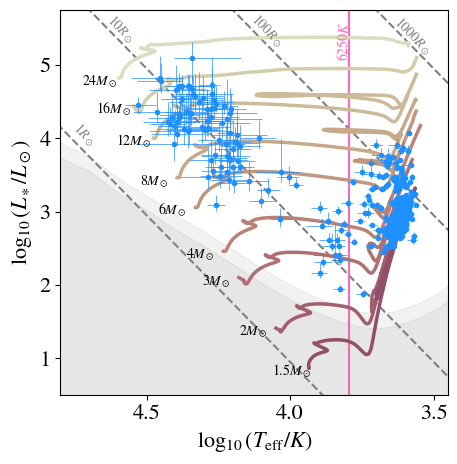

In [12]:

myfeh = -0.5
mlist = [24,16,12,8,6,4,3,2,1.5]
pal = sns.cubehelix_palette(len(mlist), start=0,rot=0.6,light=0.85,dark=0.4)

from isochrones.mist.bc import MISTBolometricCorrectionGrid

bc_grid = MISTBolometricCorrectionGrid(['I'])
tl = np.logspace(3.4,5.,100)
mbl_lmc = 19 - 5*np.log10(49.59e3) + 5 + bc_grid.interp([tl, 2,myfeh,0.0])
logll_lmc = -0.4*(mbl_lmc-4.74) 

mbl_smc = 19 - 5*np.log10(62.44e3) + 5 + bc_grid.interp([tl, 2,myfeh,0.0])
logll_smc = -0.4*(mbl_smc-4.74) 




plt.figure(figsize=(5,5))

for i,m in enumerate(mlist):
    tr = get_track(df,myfeh,m)
    sel = (tr['phase']>-1) & (tr['phase']<=4)
    plt.annotate(str(m)+"$M_\odot$",
                 (np.array(tr['logTeff'][sel])[0]+0.13,np.array(tr['logL'][sel])[0]-0.1),fontsize=10)
    plt.plot(tr['logTeff'][sel],tr['logL'][sel],'-',lw=2.5,color=pal[i])
plt.xlim(4.8,3.45)
plt.ylim(0.5,5.75)

plt.errorbar(x=np.log10(hb['teff']),y=np.log10(hb['L']),
             xerr=[np.log10(np.exp(1))*hb['teff_err-']/hb['teff'],np.log10(np.exp(1))*hb['teff_err+']/hb['teff']],
             yerr=[np.log10(np.exp(1))*hb['L_err-']/hb['L'],np.log10(np.exp(1))*hb['L_err+']/hb['L']],
             linestyle='',
              alpha=1,color='DodgerBlue',rasterized=True,
            elinewidth=0.5,marker='o',markersize=3)

plt.xlabel(r"$\log_{10}\left(T_{\rm eff}/K\right)$")
plt.ylabel(r"$\log_{10}\left(L_\ast/L_\odot\right)$")

xp = np.linspace(5,3,100)
for rr in np.logspace(0,3,4):
    plt.plot(xp,np.log10(4*np.pi*(rr*c.rsun)**2 * c.sigmaSB * (10**xp)**4 /c.lsun),zorder=0,ls='--',color='grey' )

plt.annotate("$1 R_\odot$",(4.77,3.9),fontsize=10,rotation=-45,color='grey')
plt.annotate("$10 R_\odot$",(4.65,5.3),fontsize=10,rotation=-45,color='grey')
plt.annotate("$100 R_\odot$",(4.15,5.25),fontsize=10,rotation=-45,color='grey')
plt.annotate("$1000 R_\odot$",(3.65,5.15),fontsize=10,rotation=-45,color='grey')   
    
plt.axvline(np.log10(6250),color='HotPink',zorder=0)
plt.annotate('$6250K$',(3.84,5.1),rotation=90,color='HotPink',fontsize=10)

plt.fill_between(np.log10(tl),logll_lmc.flatten(),0,color='grey',alpha=0.1 )
plt.fill_between(np.log10(tl),logll_smc.flatten(),0,color='grey',alpha=0.1 )

plt.savefig("figs/HRD_err.pdf",bbox_inches='tight',dpi=300)        

/var/folders/60/1rg8nv516mb287lhl_lqcz_00000gq/T/ipykernel_12463/3295833072.py:10: RuntimeWarning: invalid value encountered in sqrt
  axs[0].plot(xp,np.sqrt(1-(p0/xp)**(2/3.)),ls='--',color='grey',zorder=0 ,rasterized=True)


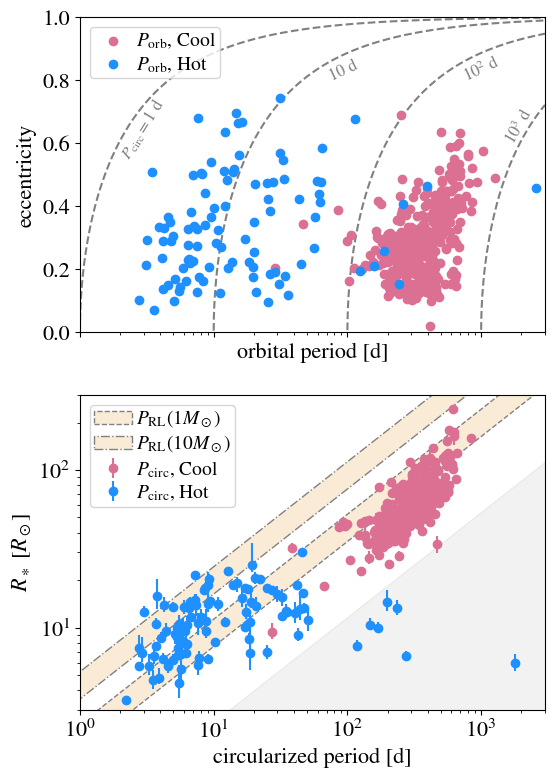

In [12]:
fig,axs = plt.subplots(2,1,figsize=(6,9),sharex=True)

HotC = 'DodgerBlue'
CoolC = 'PaleVioletRed'
selc = hb['teff']<6250.
axs[0].scatter(hb['P'][selc],hb['Ecc'][selc],c=CoolC,label=r'$P_{\rm orb}$, Cool' ,rasterized=True)
axs[0].scatter(hb['P'][selc==False],hb['Ecc'][selc==False],c=HotC,label=r'$P_{\rm orb}$, Hot' ,rasterized=True)
xp = np.logspace(0,4,100000)
for p0 in np.logspace(0,3,4):
    axs[0].plot(xp,np.sqrt(1-(p0/xp)**(2/3.)),ls='--',color='grey',zorder=0 ,rasterized=True)
axs[0].semilogx()
axs[0].set_ylim(0,1)
axs[0].set_xlim(1,3000)

axs[0].set_xlabel("orbital period [d]")
axs[0].set_ylabel("eccentricity")
axs[0].legend(loc='upper left')
#plt.savefig("figs/PeriodEccentricity.pdf",bbox_inches='tight',dpi=300)
axs[0].annotate(r'$P_{\rm circ}=1$ d',(1.9,0.55),rotation=58,color='grey',fontsize=12)
axs[0].annotate(r'10 d',(70,0.8),rotation=25,color='grey',fontsize=12)
axs[0].annotate(r'$10^2$ d',(700,0.8),rotation=25,color='grey',fontsize=12)
axs[0].annotate(r'$10^3$ d',(1400,0.6),rotation=60,color='grey',fontsize=12)


#axs[1].scatter(hb['Pcirc'][selc],hb['rad'][selc],label=r'$P_{\rm circ}$, Cool',color=CoolC,rasterized=True)
#axs[1].scatter(hb['Pcirc'][selc==False],hb['rad'][selc==False],label=r'$P_{\rm circ}$, Hot',color=HotC,rasterized=True)
axs[1].errorbar(hb['Pcirc'][selc],hb['rad'][selc],
                label=r'$P_{\rm circ}$, Cool',color=CoolC,rasterized=True,
               linestyle='',marker='o',
               yerr=[hb['rad_err-'][selc],hb['rad_err+'][selc]])
axs[1].errorbar(hb['Pcirc'][selc==False],hb['rad'][selc==False],label=r'$P_{\rm circ}$, Hot',
                color=HotC,rasterized=True,linestyle='',marker='o',
                yerr=[hb['rad_err-'][selc==False],hb['rad_err+'][selc==False]])
#axs[1].colorbar(label=r"$\log_{10}\left(T_{\rm eff}/K\right)$",extend='both',shrink=0.8)
axs[1].loglog()
xp = np.logspace(0,3)
#axs[1].plot(2*np.pi*np.sqrt( (a_RL(0.3)*xp*c.rsun)**3/(c.G*c.msun) )/86400.,xp,'--',color='grey',label=r'$P_{\rm RL} (1M_\odot)$')
#axs[1].plot(2*np.pi*np.sqrt( (a_RL(0.3)*xp*c.rsun)**3/(c.G*10*c.msun) )/86400.,xp,'-.',color='grey',label=r'$P_{\rm RL} (10M_\odot)$')

axs[1].fill_betweenx(y=xp,
                     x1=2*np.pi*np.sqrt( (a_RL(0.1)*xp*c.rsun)**3/(c.G*c.msun) )/86400.,
                     x2=2*np.pi*np.sqrt( (a_RL(0.9)*xp*c.rsun)**3/(c.G*c.msun) )/86400.,
                     ls='--',facecolor='antiquewhite',edgecolor='grey',lw=1,label=r'$P_{\rm RL} (1M_\odot)$')

axs[1].fill_betweenx(y=xp,
                     x1=2*np.pi*np.sqrt( (a_RL(0.1)*xp*c.rsun)**3/(c.G*10*c.msun) )/86400.,
                     x2=2*np.pi*np.sqrt( (a_RL(0.9)*xp*c.rsun)**3/(c.G*10*c.msun) )/86400.,
                     ls='-.',facecolor='antiquewhite',edgecolor='grey',lw=1,label=r'$P_{\rm RL} (10M_\odot)$')


axs[1].set_ylim(3,300)
axs[1].set_ylabel(r'$R_\ast$ [$R_\odot$]')
axs[1].set_xlabel('circularized period [d]')
axs[1].legend(loc='upper left')

axs[1].fill_between(p_cut(xp),xp,y2=1e-2,color='grey',alpha=0.1)


plt.subplots_adjust(hspace=0.2)
plt.savefig('figs/periods.pdf',bbox_inches='tight',dpi=300)

/var/folders/60/1rg8nv516mb287lhl_lqcz_00000gq/T/ipykernel_66834/2234769838.py:12: RuntimeWarning: invalid value encountered in sqrt
  axs[0].plot(xp,np.sqrt(1-(p0/xp)**(2/3.)),ls='--',color='grey',zorder=0 ,rasterized=True)
/var/folders/60/1rg8nv516mb287lhl_lqcz_00000gq/T/ipykernel_66834/1928255425.py:58: RuntimeWarning: divide by zero encountered in log10
  logA = np.log10(A_b)


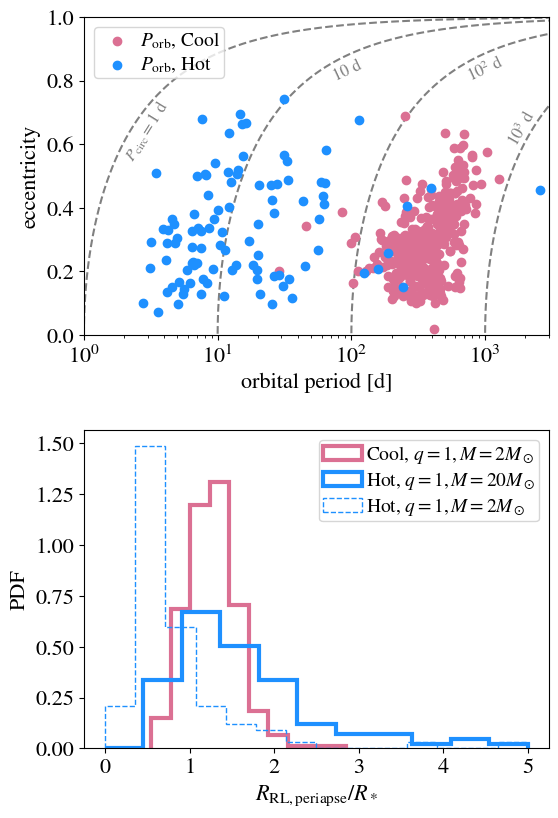

In [27]:
fig,axs = plt.subplots(2,1,figsize=(6,9.5),sharex=False)

## Period -- Eccentricity

HotC = 'DodgerBlue'
CoolC = 'PaleVioletRed'
selc = hb['teff']<6250.
axs[0].scatter(hb['P'][selc],hb['Ecc'][selc],c=CoolC,label=r'$P_{\rm orb}$, Cool' ,rasterized=True)
axs[0].scatter(hb['P'][selc==False],hb['Ecc'][selc==False],c=HotC,label=r'$P_{\rm orb}$, Hot' ,rasterized=True)
xp = np.logspace(0,4,100000)
for p0 in np.logspace(0,3,4):
    axs[0].plot(xp,np.sqrt(1-(p0/xp)**(2/3.)),ls='--',color='grey',zorder=0 ,rasterized=True)
axs[0].semilogx()
axs[0].set_ylim(0,1)
axs[0].set_xlim(1,3000)

axs[0].set_xlabel("orbital period [d]")
axs[0].set_ylabel("eccentricity")
axs[0].legend(loc='upper left')
axs[0].annotate(r'$P_{\rm circ}=1$ d',(1.9,0.55),rotation=58,color='grey',fontsize=12)
axs[0].annotate(r'10 d',(70,0.8),rotation=25,color='grey',fontsize=12)
axs[0].annotate(r'$10^2$ d',(700,0.8),rotation=25,color='grey',fontsize=12)
axs[0].annotate(r'$10^3$ d',(1400,0.6),rotation=60,color='grey',fontsize=12)

## Roche radii
axs[1].hist( roche_lobe_radius_periapse( hb['P'][selc] * 86400 , Mtot = 2*c.msun, q=1, f=0, e=hb['Ecc'][selc])  / (hb['rad'][selc]*c.rsun ),
        color=CoolC,histtype='step',linewidth=3,density=True,label='Cool, $q=1, M=2 M_\odot$',linestyle='-')
#axs[1].hist( roche_lobe_radius_periapse( hb['P'][selc] * 86400 , Mtot = 2*c.msun, q=3, f=0, e=hb['Ecc'][selc])  / (hb['rad'][selc]*c.rsun ),
#        color=CoolC,histtype='step',linewidth=1,density=True,label='Cool, $q=1/3, M=4/3 M_\odot$',linestyle='--')

axs[1].hist( roche_lobe_radius_periapse( hb['P'][selc==False] * 86400 , Mtot = 20*c.msun, q=1, f=0, e=hb['Ecc'][selc==False])  / (hb['rad'][selc==False]*c.rsun ),
        color=HotC,histtype='step',linewidth=3,density=True,label='Hot, $q=1, M=20 M_\odot$',linestyle='-',bins=np.linspace(0,5,12))
axs[1].hist( roche_lobe_radius_periapse( hb['P'][selc==False] * 86400 , Mtot = 2*c.msun, q=1, f=0, e=hb['Ecc'][selc==False])  / (hb['rad'][selc==False]*c.rsun ),
        color=HotC,histtype='step',linewidth=1,density=True,label='Hot, $q=1, M=2 M_\odot$',linestyle='--',bins=np.linspace(0,5,15))


axs[1].legend()
axs[1].set_xticks([0,1,2,3,4,5])
axs[1].set_ylabel('PDF') 
axs[1].set_xlabel(r'$R_{\rm RL, periapse} / R_*$')



plt.subplots_adjust(hspace=0.3)
plt.savefig('figs/periods_v2.pdf',bbox_inches='tight',dpi=300)

/var/folders/60/1rg8nv516mb287lhl_lqcz_00000gq/T/ipykernel_66834/1928255425.py:58: RuntimeWarning: divide by zero encountered in log10
  logA = np.log10(A_b)


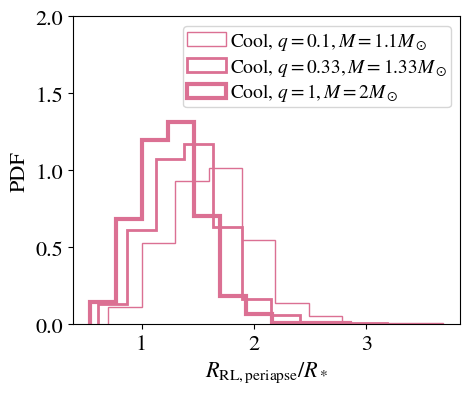

In [45]:
plt.hist( roche_lobe_radius_periapse( hb['P'][selc] * 86400 , Mtot = 1.1*c.msun, q=10, f=0, e=hb['Ecc'][selc])  / (hb['rad'][selc]*c.rsun ),
        color=CoolC,histtype='step',linewidth=1,density=True,label='Cool, $q=0.1, M=1.1 M_\odot$',linestyle='-')
plt.hist( roche_lobe_radius_periapse( hb['P'][selc] * 86400 , Mtot = 1.33*c.msun, q=3, f=0, e=hb['Ecc'][selc])  / (hb['rad'][selc]*c.rsun ),
        color=CoolC,histtype='step',linewidth=2,density=True,label='Cool, $q=0.33, M=1.33 M_\odot$',linestyle='-')
plt.hist( roche_lobe_radius_periapse( hb['P'][selc] * 86400 , Mtot = 2*c.msun, q=1, f=0, e=hb['Ecc'][selc])  / (hb['rad'][selc]*c.rsun ),
        color=CoolC,histtype='step',linewidth=3,density=True,label='Cool, $q=1, M=2 M_\odot$',linestyle='-')

plt.ylim(0,2)
plt.legend()
plt.ylabel('PDF') 
plt.xlabel(r'$R_{\rm RL, periapse} / R_*$')
plt.savefig('figs/RL_dist_vary_q.pdf',bbox_inches='tight',dpi=300) 

[-5.         -4.83333333 -4.66666667 -4.5        -4.33333333 -4.16666667
 -4.         -3.83333333 -3.66666667 -3.5        -3.33333333 -3.16666667
 -3.         -2.83333333 -2.66666667 -2.5        -2.33333333 -2.16666667
 -2.         -1.83333333 -1.66666667 -1.5        -1.33333333 -1.16666667
 -1.         -0.83333333 -0.66666667 -0.5        -0.33333333 -0.16666667
  0.        ]


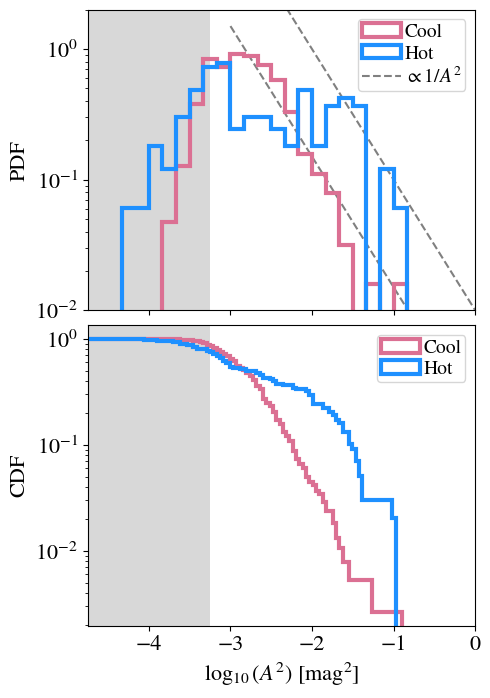

In [12]:
plt.subplots(2,1,sharex=True,figsize=(5,8))


selc = (hb['teff']<6250.) & (hb['tidal_flag']) #& (hb['Model']==1)
selh = (hb['teff']>=6250.) & (hb['tidal_flag']) #& (hb['Model']==1)

plt.subplot(211)
NbinsPDF = 31
binsPDF = np.linspace(-5,0,NbinsPDF)
print(binsPDF)
plt.hist(np.log10(hb['A_hb'][selc]**2),bins=binsPDF,color=CoolC,histtype='step',linewidth=3,density=True,label='Cool')
plt.hist(np.log10(hb['A_hb'][selc==False]**2),bins=binsPDF,color=HotC,histtype='step',linewidth=3,density=True,label='Hot')
plt.semilogy()
xp = np.logspace(-3,0)
plt.plot(np.log10(xp),1.5e-3/xp,color='grey',ls='--',zorder=0,label=r'$\propto 1/A^2$')
plt.plot(np.log10(xp),1e-2/xp,color='grey',ls='--',zorder=0)
plt.legend()
plt.xticks(visible=False)
#plt.xlabel(r'$\log_{10}\left(A^2 \right)$ [mag$^2$]')
plt.ylabel('PDF')

plt.axvspan(-3.25, -5, facecolor='grey', alpha=0.3,edgecolor='none')
#plt.xlim(-4.5,0)
plt.ylim(1e-2,2)

plt.subplot(212)
NbinsCDF = NbinsPDF*4
binsCDF = np.linspace(-5,0,NbinsCDF)
plt.hist(np.log10(hb['A_hb'][selc]**2),bins=binsCDF,color=CoolC,histtype='step',linewidth=3,density=True,label='Cool',cumulative=-1)
plt.hist(np.log10(hb['A_hb'][selc==False]**2),bins=binsCDF,color=HotC,histtype='step',linewidth=3,density=True,label='Hot',cumulative=-1)

plt.legend()

plt.xlabel(r'$\log_{10}\left(A^{2} \right)$ [mag$^2$]')
plt.ylabel('CDF')

plt.axvspan(-3.25, -5, facecolor='grey', alpha=0.3,edgecolor='none')
plt.xlim(-4.75,0)
#plt.ylim(1.e-5,1.1)
plt.semilogy()


plt.subplots_adjust(hspace=0.05)
plt.savefig("figs/AmpHist.pdf",bbox_inches='tight',dpi=300)

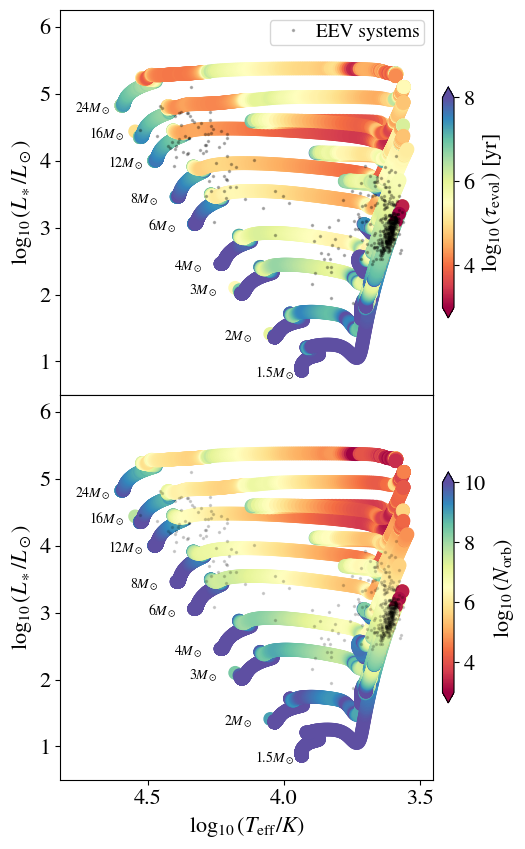

In [39]:
# Combo figure 
myfeh = -0.5
fig, axs = plt.subplots(2,1,figsize=(5.8,10),sharex=True)
mycm = 'Spectral'#'PuBuGn_r' # 'Spectral'

plt.subplot(211)
for i,m in enumerate([24,16,12,8,6,4,3,2,1.5]):
    tr = get_track(df,myfeh,m)
    sel = (tr['phase']>-1) & (tr['phase']<=4)
    rad = np.array(tr['radius'])
    time = np.array(tr['star_age'])
    radius_timescale = np.abs(rad/np.gradient(rad,time)  )
    plt.scatter(tr['logTeff'][sel],tr['logL'][sel],c=np.log10(radius_timescale)[sel],vmin=3,vmax=8,s=80 ,
               cmap=mycm,rasterized=True)
    plt.annotate(str(m)+"$M_\odot$",
                 (np.array(tr['logTeff'][sel])[0]+0.17,np.array(tr['logL'][sel])[0]-0.1),fontsize=10 )
    
plt.colorbar(extend='both',shrink=0.6,label=r'$\log_{10}\left(\tau_{\rm evol}\right)$ [yr]',pad=0.02)
plt.xlim(4.82,3.45)
plt.ylim(0.5,6.25)

sel = hb['tidal_flag']
plt.plot(np.log10(hb['teff'])[sel],np.log10(hb['L'])[sel],'.' ,alpha=0.25,color='k',markersize=3,rasterized=True,
        label='EEV systems')
plt.legend()
#plt.xlabel(r"$\log_{10}\left(T_{\rm eff}/K\right)$")
plt.ylabel(r"$\log_{10}\left(L_\ast/L_\odot\right)$")

plt.subplot(212)
Ntimes = 10000
#mycm = 'PuBuGn_r' #'Spectral_r'

for i,m in enumerate([24,16,12,8,6,4,3,2,1.5]):
    tr = get_track(df,myfeh,m)
    sel = (tr['phase']>-1) & (tr['phase']<=4)
    time = np.array(tr['star_age'])
    rad = np.array(tr['radius'])
    mass = np.array(tr['mass'])
    radius_timescale = np.abs(rad/np.gradient(rad,time)  )
    q  = 1/3
    pcirc = 2*np.pi*np.sqrt( (a_RL(q)*rad*c.rsun)**3/(c.G*mass*(1+q)*c.msun) ) / c.yr
    
    plt.scatter(tr['logTeff'][sel],tr['logL'][sel],c=np.log10(radius_timescale/pcirc)[sel],vmin=3,vmax=10,s=80 ,
               cmap=mycm,rasterized=True)

    
    plt.annotate(str(m)+"$M_\odot$",
                 (np.array(tr['logTeff'][sel])[0]+0.17,np.array(tr['logL'][sel])[0]-0.1),fontsize=10)
    
plt.colorbar(extend='both',shrink=0.6,label=r'$\log_{10}\left(N_{\rm orb}\right)$',pad=0.02)
plt.xlim(4.82,3.45)
plt.ylim(0.5,6.25)


#plt.legend()
plt.xlabel(r"$\log_{10}\left(T_{\rm eff}/K\right)$")
plt.ylabel(r"$\log_{10}\left(L_\ast/L_\odot\right)$")

sel = hb['tidal_flag']
plt.plot(np.log10(hb['teff'])[sel],np.log10(hb['L'])[sel],'.' ,alpha=0.15,color='k',markersize=3,rasterized=True,
        label='EEV systems')

#plt.axvline(np.log10(6250),color='grey',zorder=0)
plt.subplots_adjust(hspace=0)

plt.savefig("figs/HRD_tevol.pdf",bbox_inches='tight',dpi=300)

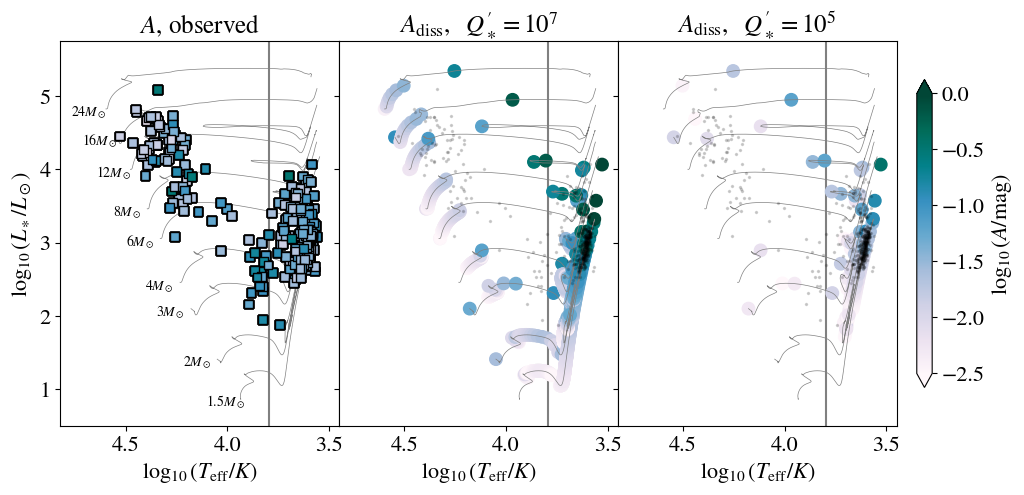

In [40]:
# Adiss vs amplitudes...
myfeh = -0.5
fig, axs = plt.subplots(1,3,figsize=(13,5),sharey=True)
#mycm = 'Spectral_r'
mycm = 'PuBuGn'
Ntimes = 10000

for k in range(len(axs)):
    for i,m in enumerate([24,16,12,8,6,4,3,2,1.5]):
        tr = get_track(df,myfeh,m)
        sel = (tr['phase']>-1) & (tr['phase']<=4)
        time = np.array(tr['star_age'])
        rad = np.array(tr['radius'])
        mass = np.array(tr['mass'])
        radius_timescale = np.abs(rad/np.gradient(rad,time)  )
        q  = 1/3
        pcirc = 2*np.pi*np.sqrt( (a_RL(q)*rad*c.rsun)**3/(c.G*mass*(1+q)*c.msun) ) / c.yr

        # evenly-spaced plotting arrays
        times_plt = np.linspace(time[sel][0],1e10,Ntimes)
        logTeff_plt = np.interp(times_plt,time,tr['logTeff'])
        logL_plt = np.interp(times_plt,time,tr['logL'])
        if k==2:
            Q=1e5
        if k==1:
            Q=10**7
        
        selhb = hb['tidal_flag']
        if k==0:
            axs[k].scatter(np.log10(hb['teff'])[selhb],np.log10(hb['L'])[selhb],c=np.log10(hb['A_hb'][selhb]) ,
            alpha=1,s=40,rasterized=True,zorder=10,cmap=mycm,vmax=0,vmin=-2.5,edgecolor='k',marker='s')
            axs[k].annotate(str(m)+"$M_\odot$",
                     (np.array(tr['logTeff'][sel])[0]+0.17,np.array(tr['logL'][sel])[0]-0.1),fontsize=10)
        else:
            logAcrit_plt = np.interp(times_plt,time,np.log10(np.sqrt(3*q/(2*np.pi*a_RL(q)) *  Q*pcirc/radius_timescale)),left=np.nan,right=np.nan)
            selplt = logAcrit_plt>-2.5
            im = axs[k].scatter(logTeff_plt[selplt],logL_plt[selplt],c=logAcrit_plt[selplt],
                        vmax=0,vmin=-2.5,s=80,
                        cmap=mycm,rasterized=True,label=np.where(i==0,r'$A_{\rm diss}$, 1 Myr intervals',''))
        
        

       
    
        axs[k].plot(tr['logTeff'][sel],tr['logL'][sel],'-',lw=0.5,color='grey')
        


        

plt.subplots_adjust(wspace=0.0)
plt.yticks(visible=False)
for i in range(len(axs)):
    axs[i].set_xlim(4.82,3.45)
    axs[i].set_ylim(.5,5.75)
    axs[i].set_xlabel(r'$\log_{10}\left( T_{\rm eff}/K\right)$')
    if i>0:
        axs[i].plot(np.log10(hb['teff'])[selhb],np.log10(hb['L'])[selhb],marker='.',color='k',ls='',
                        alpha=0.15,markersize=3,rasterized=True)
    axs[i].axvline(np.log10(6250),color='grey',zorder=0)

axs[0].set_ylabel(r'$\log_{10}\left( L_\ast/L_\odot \right)$')
cbar=fig.colorbar(im,label=r'$\log_{10}\left(A / {\rm mag}\right)$',ax=axs[:],shrink=0.8,pad=0.02,extend="both")
cbar.solids.set_edgecolor('face')

axs[0].set_title(r'$A$, observed',fontsize=18)
axs[1].set_title(r"$A_{\rm diss},\ \ Q_\ast' = 10^7$",fontsize=18)
axs[2].set_title(r"$A_{\rm diss},\ \ Q_\ast' = 10^5$",fontsize=18)



plt.savefig("figs/HRD_pop.pdf",bbox_inches='tight',dpi=300)

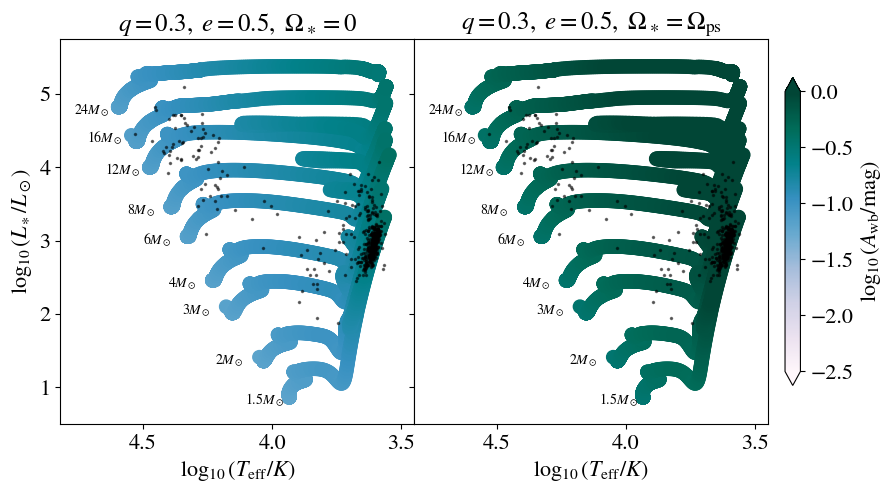

In [46]:
# Wave breaking
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'


fig, axs = plt.subplots(1,2,figsize=(11,5),sharey=True)
myfeh = -0.5
mycm = 'PuBuGn'
Ntimes = 10000

for i,m in enumerate([24,16,12,8,6,4,3,2,1.5]):
    tr = get_track(df,myfeh,m)
    sel = (tr['phase']>-1) & (tr['phase']<=4)
    tr['cs'] = np.sqrt(gamma*c.kB*10**tr['logTeff']/(0.6*c.mp))
    tr['Omega_RL'] = Omega_RL(tr['mass']*c.msun,tr['radius']*c.rsun,q=0.3)
    tr['Omega_peri'] = tr['Omega_RL']*omega_peri_factor_rp(ecc=0.5)
    tr['Omega_pseudo'] = tr['Omega_RL']*omega_pseudo_factor_rp(ecc=0.5)
    tr['Omega_tide_pseudo'] = (tr['Omega_peri']-tr['Omega_pseudo'])
    tr['Omega_tide_zero'] = (tr['Omega_peri']-0)
    tr['AoRcrit_pseudo']  = (tr['cs']/tr['Omega_tide_pseudo']) / (tr['radius']*c.rsun)
    tr['AoRcrit_zero']  = (tr['cs']/tr['Omega_tide_zero']) / (tr['radius']*c.rsun)

    axs[0].scatter(tr['logTeff'][sel],tr['logL'][sel],
                   c=np.log10(tr['AoRcrit_zero'][sel]),
                vmin=-2.5,vmax=0,s=90,
                rasterized=True,cmap=mycm)
    im=axs[1].scatter(tr['logTeff'][sel],tr['logL'][sel],
                      c=np.log10(tr['AoRcrit_pseudo'][sel]),
                vmin=-2.5,vmax=0,s=90,
                rasterized=True,cmap=mycm)
    axs[0].annotate(str(m)+"$M_\odot$",
                     (np.array(tr['logTeff'][sel])[0]+0.17,np.array(tr['logL'][sel])[0]-0.1),fontsize=10)
    axs[1].annotate(str(m)+"$M_\odot$",
                     (np.array(tr['logTeff'][sel])[0]+0.17,np.array(tr['logL'][sel])[0]-0.1),fontsize=10)


plt.subplots_adjust(wspace=0.0)
plt.yticks(visible=False)
for i in range(len(axs)):
    axs[i].set_xlim(4.82,3.45)
    axs[i].set_ylim(.5,5.75)
axs[0].set_xlabel(r'$\log_{10}\left( T_{\rm eff}/K\right)$')
axs[1].set_xlabel(r'$\log_{10}\left( T_{\rm eff}/K\right)$')
axs[0].set_ylabel(r'$\log_{10}\left( L_\ast /L_\odot \right)$')
cbar=fig.colorbar(im,label=r'$\log_{10}\left( A_{\rm wb} / {\rm mag}\right)$',
                  ax=axs[:],shrink=0.8,pad=0.02,extend='both')
cbar.solids.set_edgecolor('face')
axs[1].set_title(r'$q=0.3,\ e=0.5,\ \Omega_\ast=\Omega_{\rm ps}$',fontsize=18)
axs[0].set_title(r'$q=0.3,\ e=0.5,\ \Omega_\ast=0$',fontsize=18)

sel = hb['tidal_flag'] #& (hb['Model']==1)
axs[0].plot(np.log10(hb['teff'])[sel],np.log10(hb['L'])[sel],'.' ,alpha=0.5,color='k',markersize=3,rasterized=True)
axs[1].plot(np.log10(hb['teff'])[sel],np.log10(hb['L'])[sel],'.' ,alpha=0.5,color='k',markersize=3,rasterized=True)

plt.savefig("figs/AcritHRD.pdf",bbox_inches='tight',dpi=300)

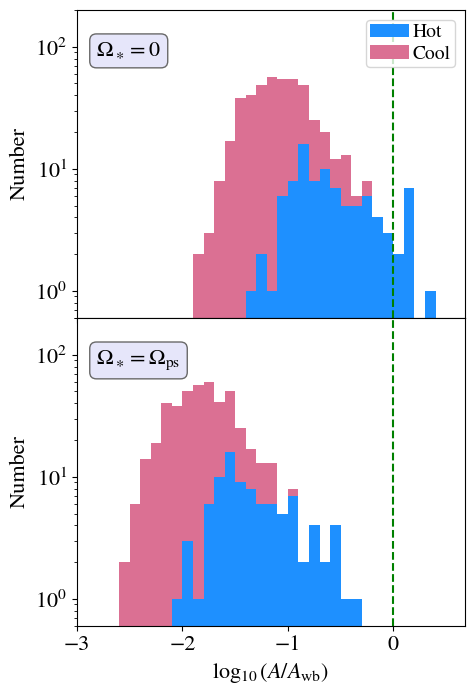

In [43]:
fig,axs = plt.subplots(2,1,figsize=(5,8),sharex=True)

axs[0].hist( [np.log10(hb[selh]['f_crit_zero']),
              np.log10(hb[selc]['f_crit_zero'])],
         histtype='barstacked',label=['Hot','Cool'],bins=np.linspace(-3,0.5,36) ,color=[HotC,CoolC],rasterized=True)
axs[0].legend(loc='upper right')
axs[0].semilogy()
axs[0].axvline(0,ls='--',color='green')
axs[0].set_ylim(0.6,2e2)
axs[0].set_xlim(-3,)
axs[0].set_ylabel("Number")
axs[0].annotate(r'$\Omega_\ast =0$',(0.05,0.85),xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="lavender", ec="dimgrey"))

axs[1].hist( [np.log10(hb[selh]['f_crit_pseudo']),
              np.log10(hb[selc]['f_crit_pseudo'])],
         histtype='barstacked',label=['Hot','Cool'],bins=np.linspace(-3,0.5,36) ,color=[HotC,CoolC],rasterized=True)
axs[1].semilogy()
axs[1].axvline(0,ls='--',color='green')
axs[1].set_ylim(0.6,2e2)
axs[1].set_ylabel("Number")
axs[1].annotate(r'$\Omega_\ast =\Omega_{\rm ps}$',(0.05,0.85),xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="lavender", ec="dimgrey"))


axs[1].set_xlabel(r"$\log_{10}( A / A_{\rm wb} )$")
fig.subplots_adjust(hspace=0)
plt.savefig("figs/AcritHist.pdf",bbox_inches='tight',dpi=300)

In [17]:
hbt = hb[hb['tidal_flag']].copy()
hbt.sort('f_crit_pseudo')
hbt.reverse()

print( hbt[0:15] )

       ID        Type      RA     ...    f_crit_zero        f_crit_pseudo   
---------------- ---- ----------- ... ------------------ -------------------
OGLE-LMC-HB-0254   MS 05:26:24.45 ... 2.4569178556727858  0.4601839210610165
OGLE-LMC-HB-0292   MS 05:30:18.89 ...  1.584545208317643  0.3169634737796834
OGLE-LMC-HB-0337   MS 05:35:06.34 ... 1.3663549041908805  0.2642704013683303
OGLE-SMC-HB-0006   MS 00:45:25.85 ... 1.4465212965953593  0.2623362229113199
OGLE-SMC-HB-0001   MS 00:22:01.64 ...  1.330490711572161   0.262212352054648
OGLE-LMC-HB-0185   MS 05:17:44.82 ... 1.4048505773888187 0.26158951357444515
OGLE-LMC-HB-0408   MS 05:46:15.42 ... 1.2779874342181425 0.23186828237206278
OGLE-LMC-HB-0154   MS 05:14:44.32 ... 1.3857564127877908 0.21402222523455558
OGLE-SMC-HB-0037   MS 01:10:42.43 ... 1.0069329989369138 0.19580989804563922
OGLE-SMC-HB-0004   MS 00:44:17.74 ...  1.016861397678001  0.1948522308076812
OGLE-LMC-HB-0032   MS 04:55:47.83 ... 0.9564140660793338 0.17151842365758507

In [18]:
hbt[0:3]

ID,Type,RA,Decl,I,V,V_I,P,T0,A,Ecc,Incl,Peri,Model,loc,teff,teff_err-,teff_err+,logg,logg_err-,logg_err+,L,L_err-,L_err+,rad,rad_err-,rad_err+,ebv,ebv_err-,ebv_err+,Pcirc,cs,Omega_orb,Omega_peri,Omega_pseudo,AoRcrit_zero,Omega_tide_pseudo,AoRcrit_pseudo,tidal_flag,A_adjust,A_hb,f_crit_zero,f_crit_pseudo
str16,str2,str11,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str3,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64
OGLE-LMC-HB-0254,MS,05:26:24.45,-68:47:05.0,13.473,13.772,0.299,32.82939,9031.003,0.321,0.5473,42.51,130.64,1,LMC,21947.78805414513,8651.66111116606,3202.9361395778687,3.043277964552831,0.5232848099431058,0.14929438350571855,124025.2400973859,89221.59702150049,63150.48299599906,25.011605787168705,2.5372500573213443,9.463671216284737,0.2621479291372661,0.09530478296769462,0.05692568698270173,19.24599387592406,2056022.8592363456,2.2151508805503365e-06,9.046380146404204e-06,7.35198133792599e-06,0.13065149868923864,1.6943988084782146e-06,0.6975471877850293,True,nan,0.321,2.4569178556727858,0.4601839210610165
OGLE-LMC-HB-0292,MS,05:30:18.89,-70:26:24.5,15.908,15.948,0.04,3.1858559,9001.6509,0.147,0.292,89.5,147.4,0,LMC,22458.191617837376,5191.397775022717,4146.61858652881,3.4034924014769072,0.5449602718690478,0.6110111427157316,13131.66312032727,6165.87967970524,9085.336793478822,7.400971794133941,0.9220226249864485,1.5395989147996207,0.11427070594383615,0.04690026462708563,0.042035741411027366,2.7872106018865113,2079792.2310797109,2.2826535301370787e-05,4.3553330202382426e-05,3.484116802287749e-05,0.09277109875336034,8.712162179504934e-06,0.4637758358938781,True,nan,0.147,1.584545208317643,0.3169634737796834
OGLE-LMC-HB-0337,MS,05:35:06.34,-70:16:26.5,16.465,17.078,0.613,18.350478,9003.916,0.196,0.221,89.9,45.35,0,LMC,6648.554441546483,327.2682328306564,362.767958987205,2.652320035684836,0.49273111901068267,0.5826872090378963,558.7895034359577,66.02617689271392,89.77525214140553,17.80885914807958,1.0197876285123257,1.095103796109317,0.1120369384160662,0.049092496780849024,0.05151503801201564,17.022645846994646,1131608.4316888982,3.962951382870266e-06,6.368987403506037e-06,5.137144306026844e-06,0.1434473571974816,1.2318430974791925e-06,0.7416645942381662,True,nan,0.196,1.3663549041908805,0.2642704013683303


In [19]:
hbtm = hb[hb['tidal_flag'] & (hb['Model']==1)].copy()
hbtm.sort('f_crit_pseudo')
hbtm.reverse()

print( hbtm[0:15] )

       ID        Type      RA     ...     f_crit_zero        f_crit_pseudo    
---------------- ---- ----------- ... ------------------- --------------------
OGLE-LMC-HB-0254   MS 05:26:24.45 ...  2.4569178556727858   0.4601839210610165
OGLE-SMC-HB-0006   MS 00:45:25.85 ...  1.4465212965953593   0.2623362229113199
OGLE-LMC-HB-0404   MS 05:46:01.61 ...  0.7499138159657879  0.15006009789130115
OGLE-SMC-HB-0005   MS 00:44:46.60 ...  0.6330347392276399  0.12358092297147663
OGLE-LMC-HB-0266   MS 05:27:29.73 ...  0.6476569083016078  0.11416610517313958
OGLE-LMC-HB-0329   MS 05:34:07.84 ...  0.5227239195348612  0.10405704321603097
OGLE-LMC-HB-0225   MS 05:22:00.08 ... 0.46080421530189697  0.08912539088968534
OGLE-LMC-HB-0255   MS 05:26:25.67 ...  0.4288397651038971  0.08483202459252752
OGLE-LMC-HB-0151   RG 05:14:04.85 ...  0.3689222324401915  0.07356406926251141
OGLE-LMC-HB-0290   MS 05:30:02.38 ...  0.3527906121498019  0.06673860543859284
OGLE-LMC-HB-0224   RG 05:21:53.51 ...  0.33330363248

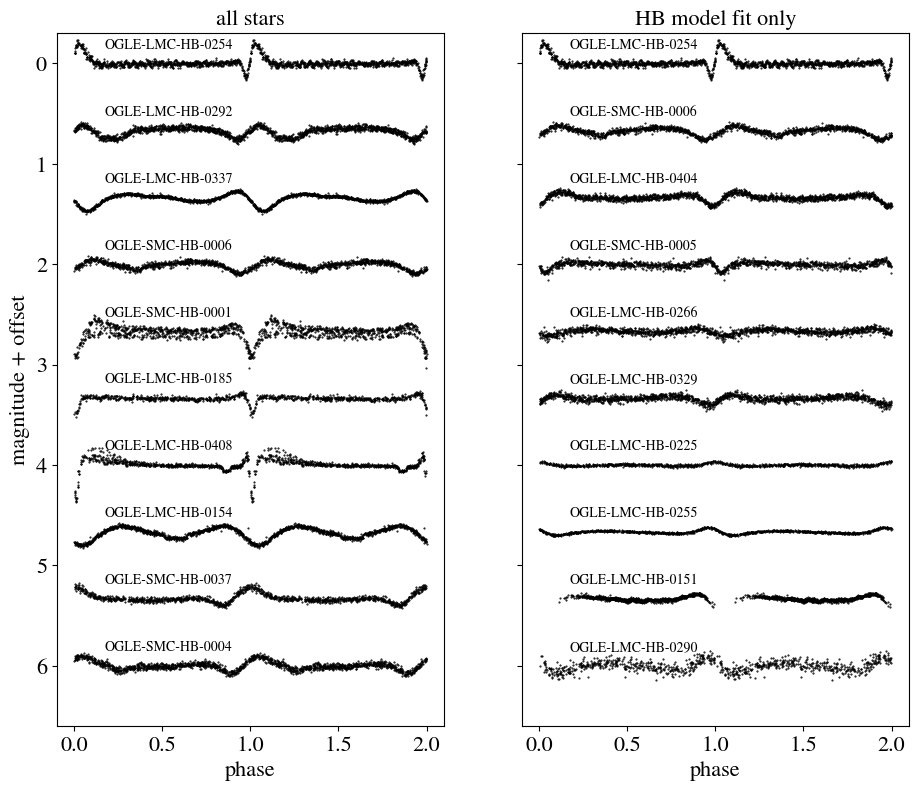

In [20]:
def read_phase_phot(ID):
    fn = "ogle_lc_data/" + ID + ".dat"
    phot = Table.read(fn,format='ascii',names=['mjd','mag','mag_err'])
    
    sel = hb['ID']==ID
    t0 = hb[sel]['T0'][0]
    per = hb[sel]['P'][0]
    phot['phase'] = ((phot['mjd']-t0)%per )/per
    phot['mag_zeroed']  = phot['mag']-np.median(phot['mag'])  
    return phot 


#phot = read_phase_phot('OGLE-LMC-HB-0254')
#plt.plot(phot['phase'],phot['mag'],'k.')
#plt.plot(phot['phase']+1,phot['mag'],'k.')
#phot

plt.subplots(1,2, sharey=True, figsize=(11,9))
ms = 1
off_fac = 1.5

plt.subplot(121)
for i in range(10):
    try:
        phot = read_phase_phot(hbt['ID'][i])
        offset_mag = i/off_fac
        plt.plot(phot['phase'],phot['mag_zeroed']+offset_mag,'k.',markersize=ms,rasterized=True)
        plt.plot(phot['phase']+1,phot['mag_zeroed']+offset_mag,'k.',markersize=ms,rasterized=True)
        plt.annotate(hbt['ID'][i],(0.17,offset_mag - 0.15),fontsize=10 ) 
    except:
        print('couldnt find:',hbt['ID'][i])
        


plt.ylim(6.6,-0.3)
plt.xlabel('phase')
plt.ylabel('magnitude + offset')
plt.title('all stars',fontsize=16)

plt.subplot(122)
for i in range(10):
    try:
        phot = read_phase_phot(hbtm['ID'][i])
        offset_mag = i/off_fac
        plt.plot(phot['phase'],phot['mag_zeroed']+offset_mag,'k.',markersize=ms,rasterized=True)
        plt.plot(phot['phase']+1,phot['mag_zeroed']+offset_mag,'k.',markersize=ms,rasterized=True)
        plt.annotate(hbtm['ID'][i],(0.17,offset_mag - 0.15),fontsize=10 ) 
    except:
        print('couldnt find:',hbtm['ID'][i])
    
plt.ylim(6.6,-0.3)

plt.title('HB model fit only',fontsize=16)
plt.xlabel('phase')
plt.savefig('figs/lc_gallery.pdf',dpi=300, bbox_inches='tight')

In [21]:
def Q_eq(Q0,omega_tide,omega_conv,mode='mlt'):
    """
    MLT based definition of diss of Eq tide in convective zone. 
    \nu_E ~ 1/3 * u_conv * l_conv, integrated over stellar model. 
    
    ptide: tidal period (days)
    mode: "mlt", "zahn", "GN", 'fit'
    Q0: nominal value of Q at ptide=1day
    pconv: convective period (days)
    
    I approximate that here by selecting a value of Q0, then scaling. 
    
    ptide in days, Q' is dimensionless
    
    source: Barker: MNRAS 498, 2270–2294 (2020) , eq 20-27
    
    """
    om = omega_tide
    omc = omega_conv
    
    if mode=='mlt':
        factor=1
    elif mode=='zahn':
        factor = (1+(om/(np.pi*omc))**2)**-0.5
    elif mode=='GN':
        factor = (1+(om/omc)**2)**-1
    elif mode=='fit':
        factor = 3*np.where(om/omc<1.e-2,5,
                    np.where(om/omc<5,0.5*(omc/om)**0.5,
                         25/np.sqrt(20) * (omc/om)**2))
        
    return  Q0 / factor


# estimating Q 
ms = 2*c.msun
rs = 100*c.rsun
ls = 1000*c.lsun
q = 1/3.

# frequencies
tconv = (ms*rs**2/ls)**(1/3)
omf = np.sqrt(c.G*ms/rs**3)
omc = 1/tconv
om = Omega_RL((1+q)*ms, rs, q) 

k2 = 0.03
Q0 = tconv*omf**2 / om
Q0p = 1.5*Q0/k2
QpGN = Q_eq(Q0p,om,omc,mode='GN')
QpD = Q_eq(Q0p,om,omc,mode='fit')



print("tconv/yr=",tconv/c.yr)
print("porb/yr =",2*np.pi/om / c.yr)
print("Q (mlt) =",Q0)
print("Q' (mlt)=",Q0p)
print("Q' (GN)=",QpGN)
print("Q' (fit)=",QpD)

tconv/yr= 1.1684495946367268
porb/yr = 0.5913227126444888
Q (mlt) = 86.30331274826543
Q' (mlt)= 4315.165637413272
Q' (GN)= 669478.1158765778
Q' (fit)= 39662.65527597553
